In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk

In [6]:
df = pd.read_csv("amazon_review.csv")
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4,Four Stars,1406073600,23-07-2014,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5,MOAR SPACE!!!,1382659200,25-10-2013,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4,nothing to really say....,1356220800,23-12-2012,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5,Great buy at this price!!! *** UPDATE,1384992000,21-11-2013,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5,best deal around,1373673600,13-07-2013,513,0,0


In [4]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/arnav/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/arnav/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/arnav/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
from nltk.tokenize import word_tokenize
df['reviewText']=df['reviewText'].fillna("")
df['tokens']=df['reviewText'].apply(word_tokenize)
print(df[['reviewText','tokens']].head())

                                          reviewText  \
0                                         No issues.   
1  Purchased this for my device, it worked as adv...   
2  it works as expected. I should have sprung for...   
3  This think has worked out great.Had a diff. br...   
4  Bought it with Retail Packaging, arrived legit...   

                                              tokens  
0                                    [No, issues, .]  
1  [Purchased, this, for, my, device, ,, it, work...  
2  [it, works, as, expected, ., I, should, have, ...  
3  [This, think, has, worked, out, great.Had, a, ...  
4  [Bought, it, with, Retail, Packaging, ,, arriv...  


In [9]:
df['reviewerName'] = df['reviewerName'].fillna("").str.lower()
df['reviewText'] = df['reviewText'].fillna("").str.lower()
df['summary'] = df['summary'].fillna("").str.lower()

print(df[['reviewText','reviewerName']])

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(str(text))   # properly indented
    filtered = [word for word in tokens if word.lower() not in stop_words]
    return " ".join(filtered)

df['reviewText_no_stop'] = df['reviewText'].apply(remove_stopwords)

print(df[['reviewText', 'reviewText_no_stop']].head())

                                             reviewText  reviewerName
0                                            no issues.              
1     purchased this for my device, it worked as adv...          0mie
2     it works as expected. i should have sprung for...           1k3
3     this think has worked out great.had a diff. br...           1m2
4     bought it with retail packaging, arrived legit...  2&amp;1/2men
...                                                 ...           ...
4910  i bought this sandisk 16gb class 10 to use wit...        zm "j"
4911  used this for extending the capabilities of my...            zo
4912  great card that is very fast and reliable. it ...     z s liske
4913  good amount of space for the stuff i want to d...      z taylor
4914  i've heard bad things about this 64gb micro sd...           zza

[4915 rows x 2 columns]
                                          reviewText  \
0                                         no issues.   
1  purchased this for m

In [10]:
import string
from nltk.tokenize import word_tokenize

punctuations = set(string.punctuation)

def rdfve_punctuation(text):
    tokens = word_tokenize(str(text))   # indented
    filtered_tokens = [word for word in tokens if word not in punctuations]
    return " ".join(filtered_tokens)

df['reviewText_clean'] = df['reviewText'].apply(rdfve_punctuation)
df['summary_clean'] = df['summary'].apply(rdfve_punctuation)

print(df[['reviewText', 'reviewText_clean', 'summary', 'summary_clean']].head())

                                          reviewText  \
0                                         no issues.   
1  purchased this for my device, it worked as adv...   
2  it works as expected. i should have sprung for...   
3  this think has worked out great.had a diff. br...   
4  bought it with retail packaging, arrived legit...   

                                    reviewText_clean  \
0                                          no issues   
1  purchased this for my device it worked as adve...   
2  it works as expected i should have sprung for ...   
3  this think has worked out great.had a diff bra...   
4  bought it with retail packaging arrived legit ...   

                                  summary                   summary_clean  
0                              four stars                      four stars  
1                           moar space!!!                      moar space  
2               nothing to really say....      nothing to really say ....  
3  great buy at this p

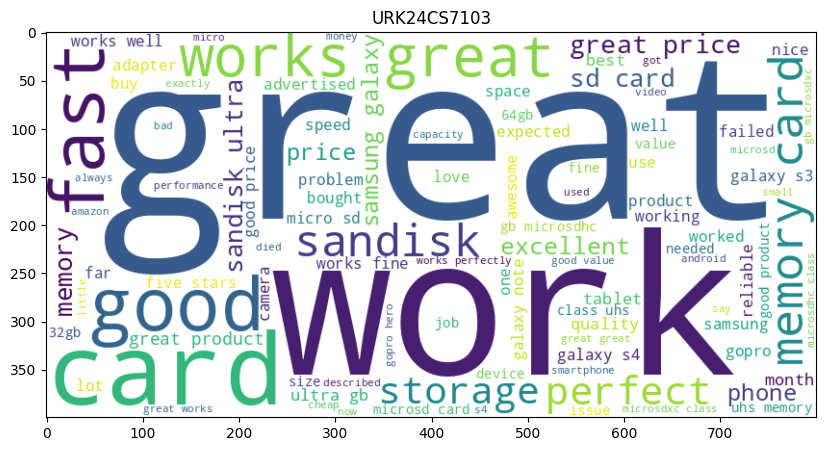

In [11]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
text = " ".join(df['summary'].astype(str))
wordcloud = WordCloud(
width=800,
height=400,
background_color='white',
max_words=100
).generate(text)
plt.figure(figsize=(10, 5))
plt.title("URK24CS7103")
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()

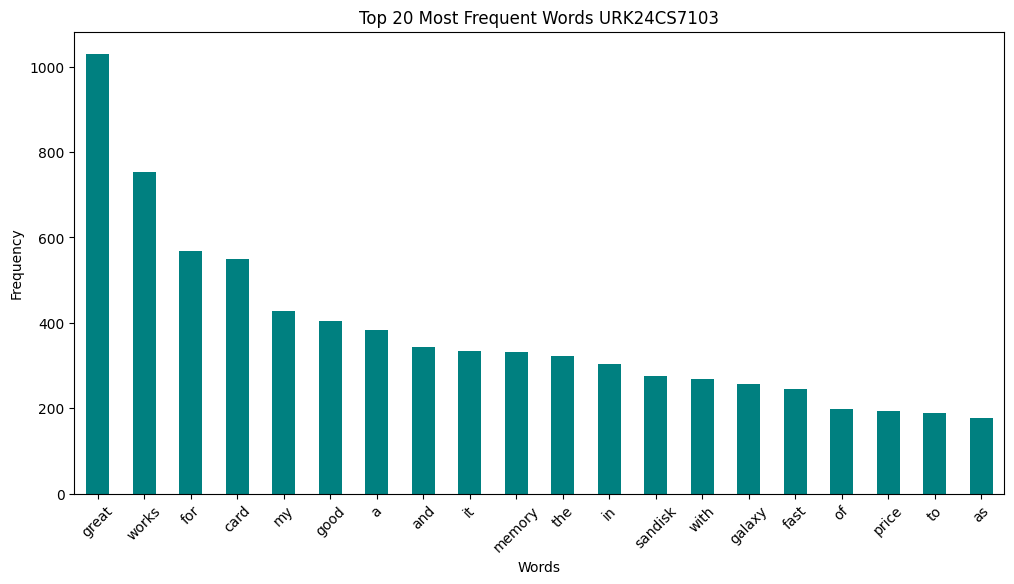

In [12]:
word_counts = df['summary'].str.split().explode().value_counts()
word_counts.head(20).plot(kind='bar', figsize=(12, 6), color='teal')
plt.title('Top 20 Most Frequent Words URK24CS7103')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

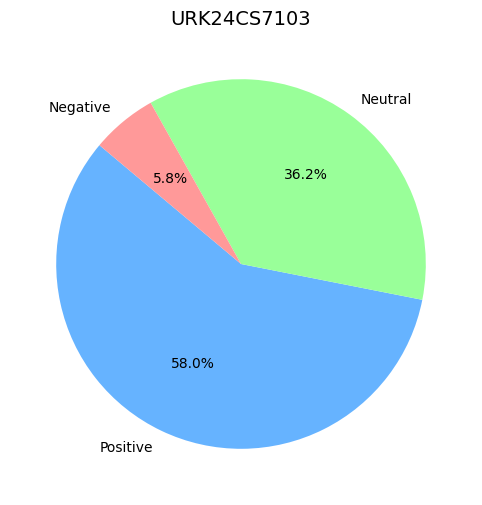

In [14]:
from textblob import TextBlob
import matplotlib.pyplot as plt

def get_sentiment_label(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['summary'].apply(get_sentiment_label)

plt.figure(figsize=(8, 6))
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff', '#99ff99', '#ff9999']
)

plt.title("URK24CS7103", fontsize=14)
plt.ylabel('')
plt.show()

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(df['summary'])

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(dtm)

words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic #{i+1}:")
    print([words[index] for index in topic.argsort()[-10:]])


Topic #1:
['gb', 'ultra', 'samsung', 'price', 'sandisk', 'galaxy', 'works', 'memory', 'card', 'great']

Topic #2:
['months', 'just', 'reliable', 'best', 'fine', 'quality', 'gopro', 'perfect', 'works', 'fast']

Topic #3:
['buy', 'does', 'note', 'excellent', 'micro', 'phone', 'sd', 'card', 'works', 'good']
